# Exploratory Data Analysis - Cervical Cancer Risk Factors

This notebook performs exploratory data analysis on the cervical cancer risk factors dataset to understand the data distribution, missing values, correlations, and key patterns.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# Load the dataset
df = pd.read_csv('kag_risk_factors_cervical_cancer.csv')

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

print('Dataset loaded successfully.')

Dataset loaded successfully.


## 1. Basic Dataset Information

In [3]:
# Display shape
print(f'Dataset Shape: {df.shape}')
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Dataset Shape: (858, 36)
Number of Rows: 858
Number of Columns: 36


In [4]:
# Display first 10 rows
df.head(10)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
5,42,3.0,23.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
6,51,3.0,17.0,6.0,1.0,34.0,3.4,0.0,0.0,1.0,...,NaN,NaN,0,0,0,0,1,1,0,1
7,26,1.0,26.0,3.0,0.0,0.0,0.0,1.0,2.0,1.0,...,NaN,NaN,0,0,0,0,0,0,0,0
8,45,1.0,20.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,1,0,1,1,0,0,0,0
9,44,3.0,15.0,NaN,1.0,1.266972909,2.8,0.0,0.0,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0


In [5]:
# Display column names
print('Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f'{i}. {col}')

Column Names:
1. Age
2. Number of sexual partners
3. First sexual intercourse
4. Num of pregnancies
5. Smokes
6. Smokes (years)
7. Smokes (packs/year)
8. Hormonal Contraceptives
9. Hormonal Contraceptives (years)
10. IUD
11. IUD (years)
12. STDs
13. STDs (number)
14. STDs:condylomatosis
15. STDs:cervical condylomatosis
16. STDs:vaginal condylomatosis
17. STDs:vulvo-perineal condylomatosis
18. STDs:syphilis
19. STDs:pelvic inflammatory disease
20. STDs:genital herpes
21. STDs:molluscum contagiosum
22. STDs:AIDS
23. STDs:HIV
24. STDs:Hepatitis B
25. STDs:HPV
26. STDs: Number of diagnosis
27. STDs: Time since first diagnosis
28. STDs: Time since last diagnosis
29. Dx:Cancer
30. Dx:CIN
31. Dx:HPV
32. Dx
33. Hinselmann
34. Schiller
35. Citology
36. Biopsy


In [7]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           832 non-null    object
 2   First sexual intercourse            851 non-null    object
 3   Num of pregnancies                  802 non-null    object
 4   Smokes                              845 non-null    object
 5   Smokes (years)                      845 non-null    object
 6   Smokes (packs/year)                 845 non-null    object
 7   Hormonal Contraceptives             750 non-null    object
 8   Hormonal Contraceptives (years)     750 non-null    object
 9   IUD                                 741 non-null    object
 10  IUD (years)                         741 non-null    object
 11  STDs                                753 non-null    object

In [8]:
# Statistical summary
df.describe()

,Age,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,0.087413,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,0.302545,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Missing Value Analysis

In [9]:
# Count missing values per column
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
}).sort_values(by='Missing Count', ascending=False)

print('Missing Values per Column:')
missing_df[missing_df['Missing Count'] > 0]

Missing Values per Column:


,Missing Count,Missing Percentage
STDs: Time since last diagnosis,787,91.724942
STDs: Time since first diagnosis,787,91.724942
IUD,117,13.636364
IUD (years),117,13.636364
Hormonal Contraceptives,108,12.587413
Hormonal Contraceptives (years),108,12.587413
STDs:pelvic inflammatory disease,105,12.237762
STDs:vulvo-perineal condylomatosis,105,12.237762
STDs:HPV,105,12.237762
STDs:Hepatitis B,105,12.237762


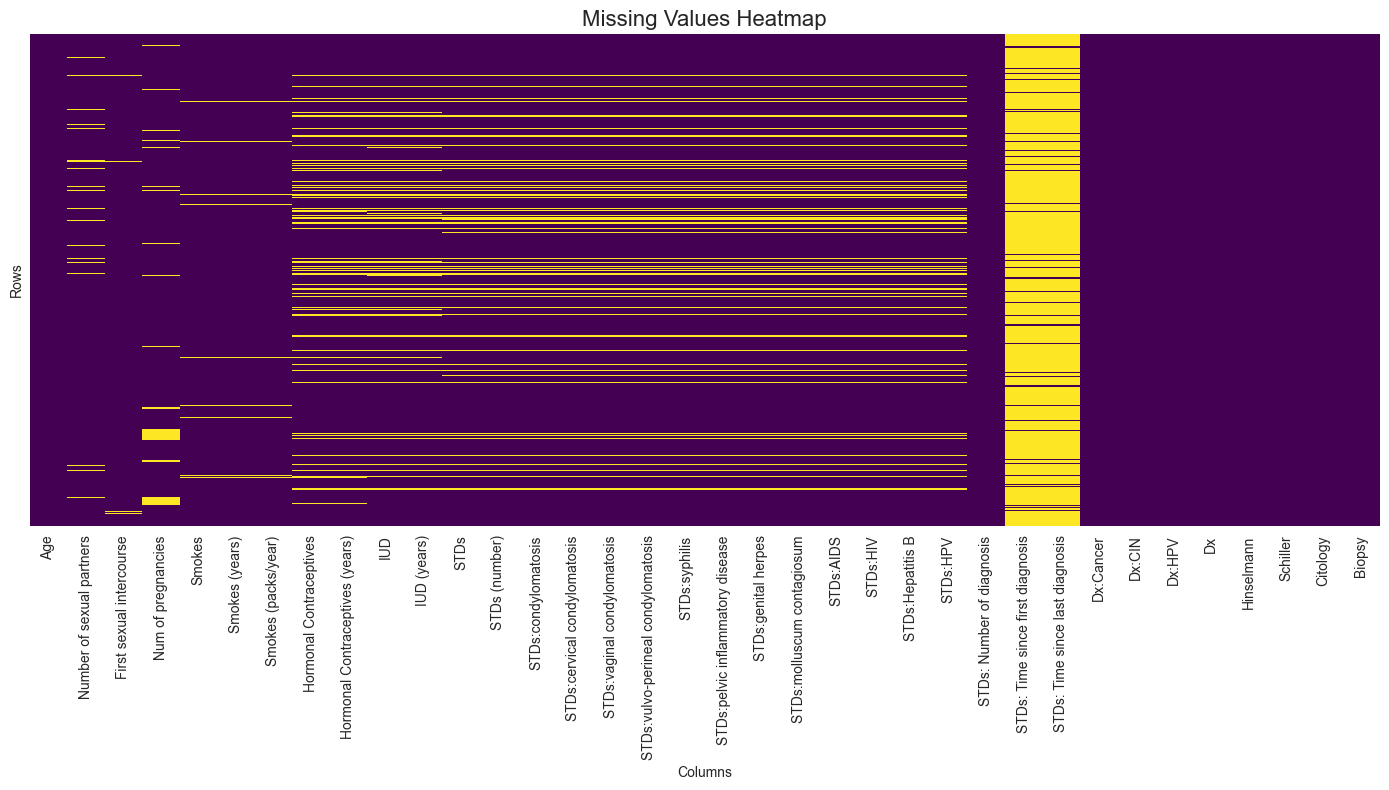

In [10]:
# Visualize missing values
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=16)
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

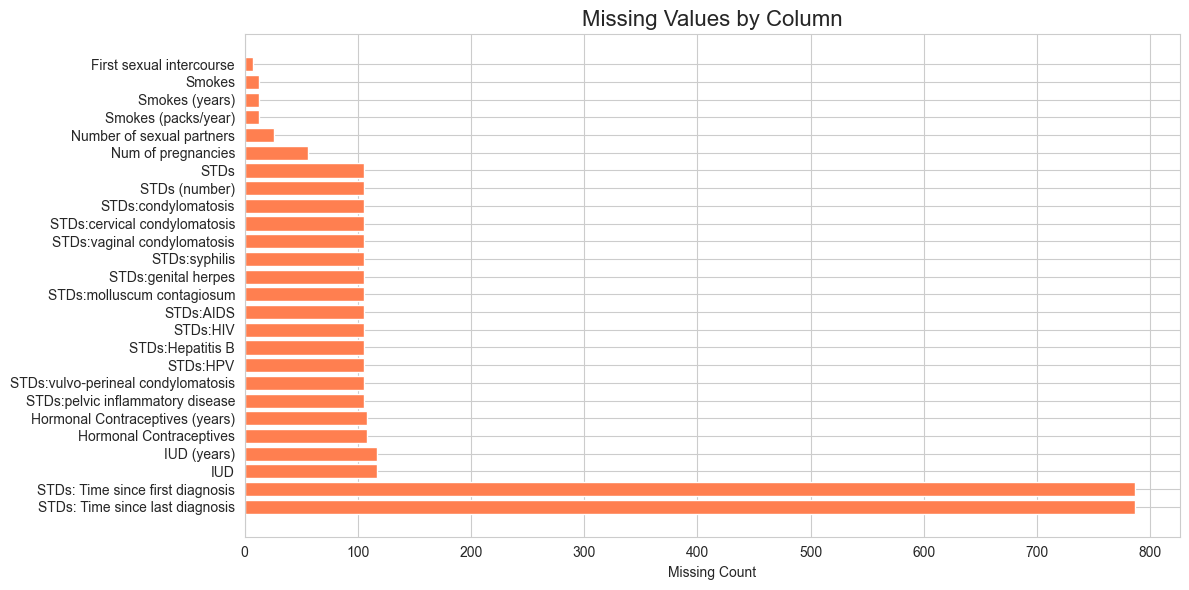

In [11]:
# Bar plot of missing values
missing_vals = missing_df[missing_df['Missing Count'] > 0]
plt.figure(figsize=(12, 6))
plt.barh(missing_vals.index, missing_vals['Missing Count'], color='coral')
plt.xlabel('Missing Count')
plt.title('Missing Values by Column', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Univariate Analysis

In [12]:
# Convert columns to numeric for analysis
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Columns converted to numeric.')

Columns converted to numeric.


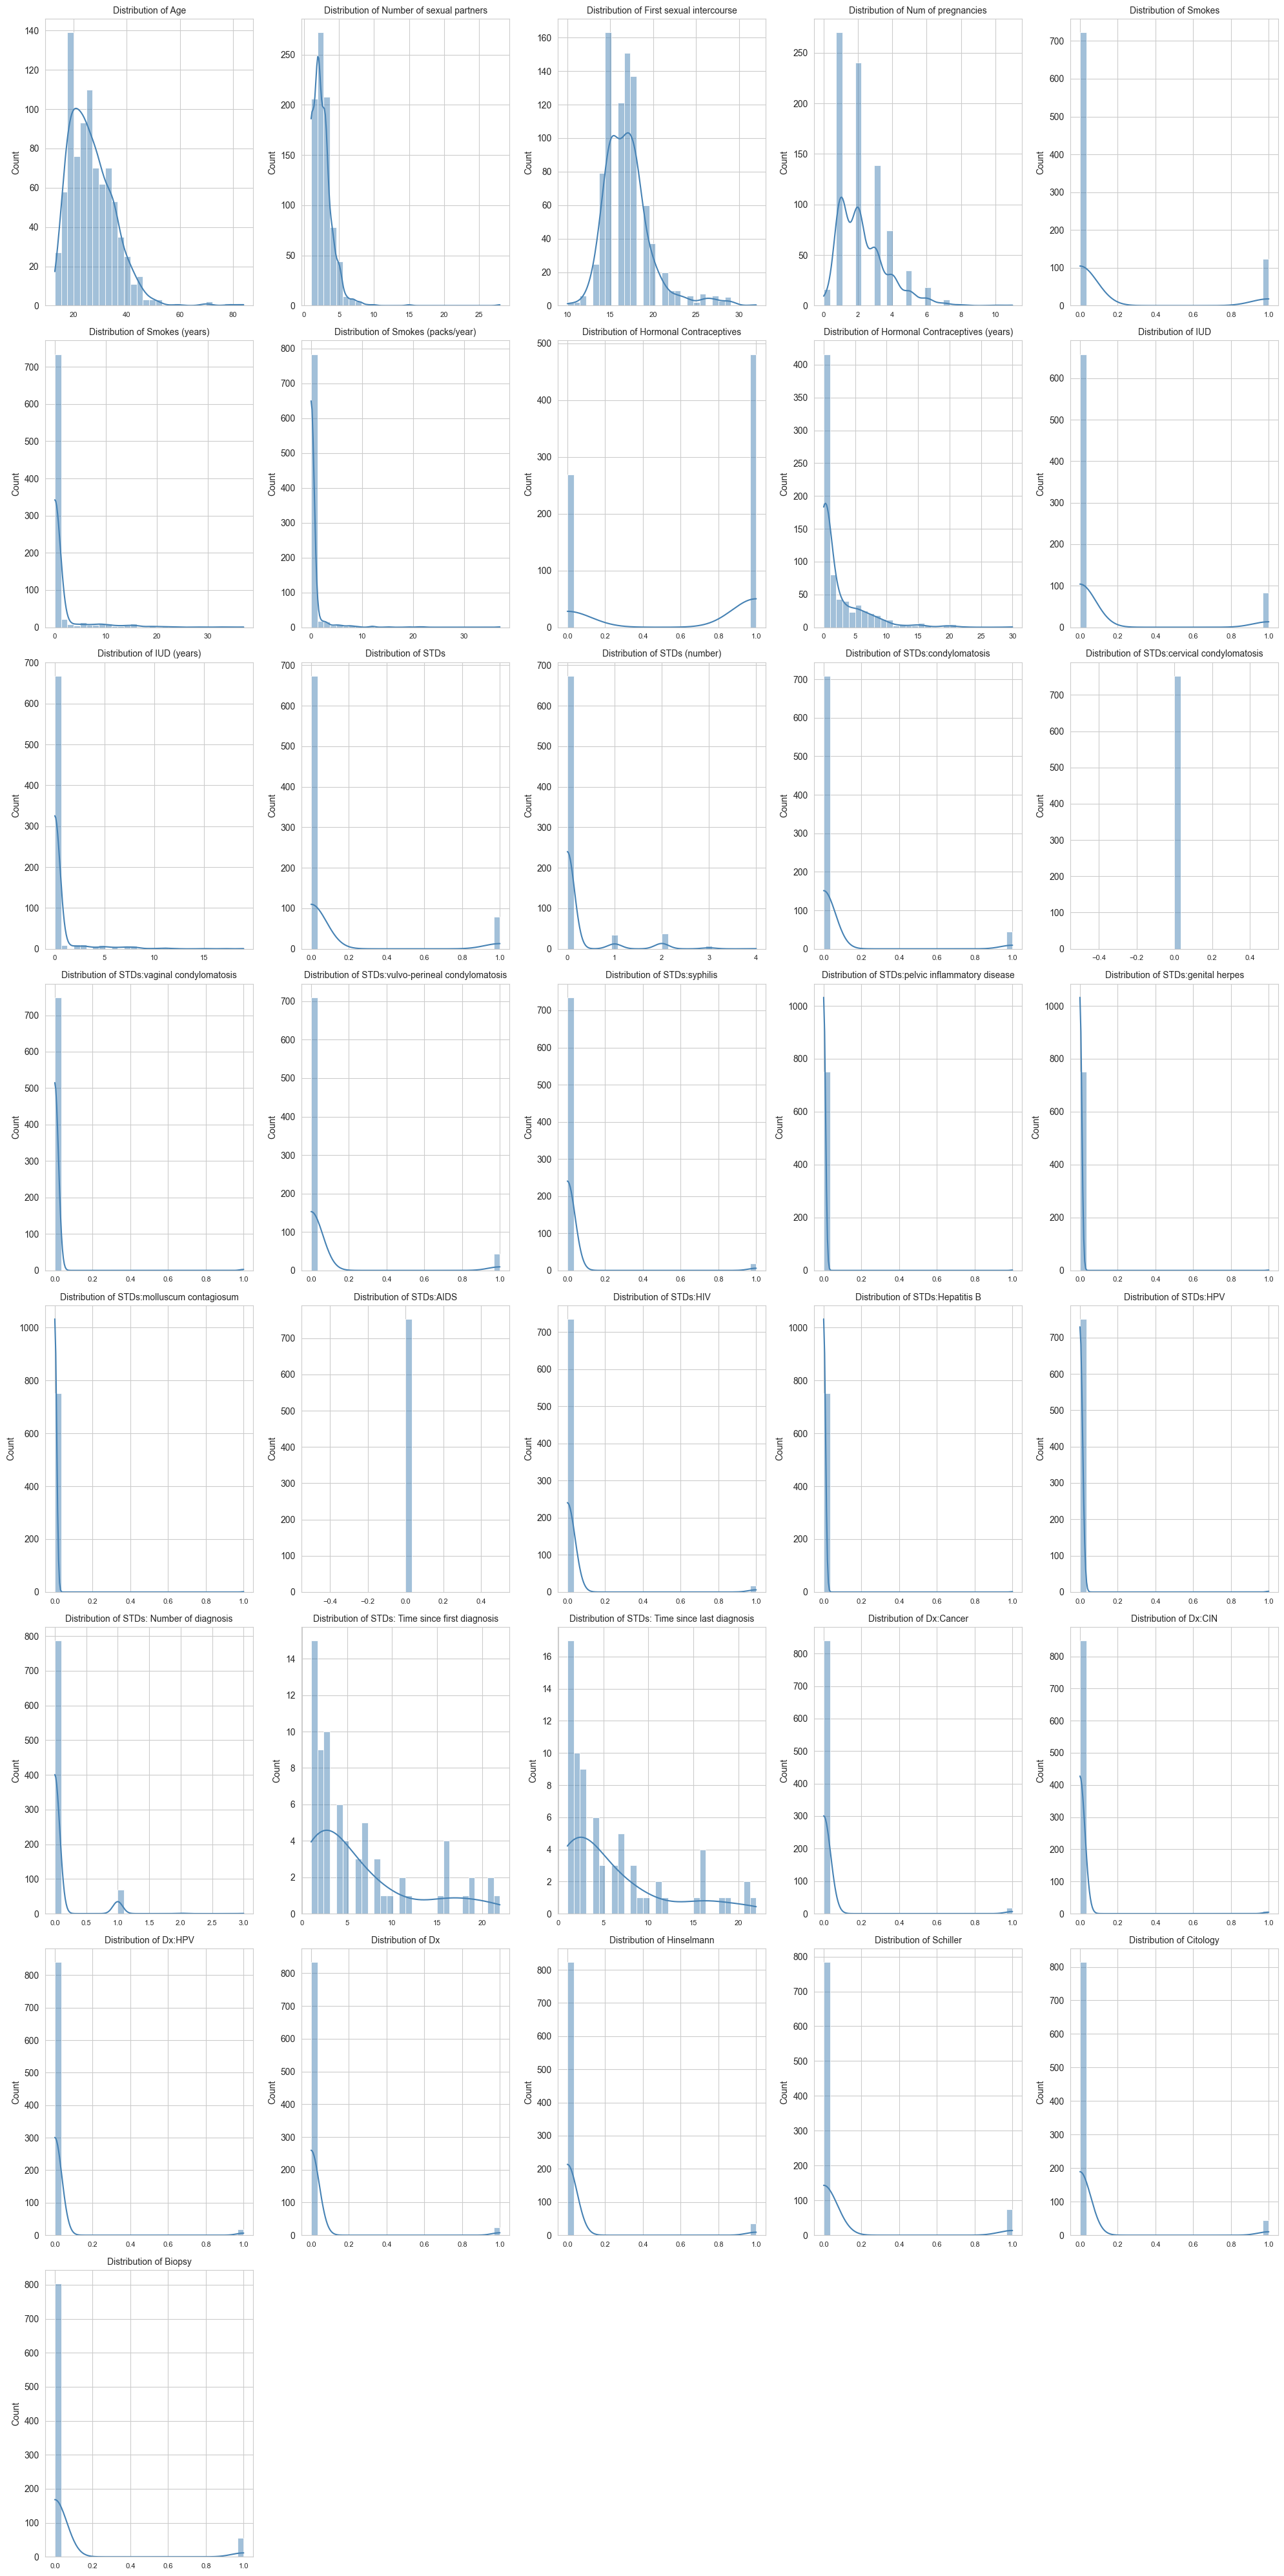

In [13]:
# Distribution of all numeric features
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = len(numeric_cols)
n_rows = int(np.ceil(n_cols / 5))

plt.figure(figsize=(20, 5 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, 5, i + 1)
    sns.histplot(df[col].dropna(), bins=30, kde=True, color='steelblue')
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.xlabel('')
    plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()

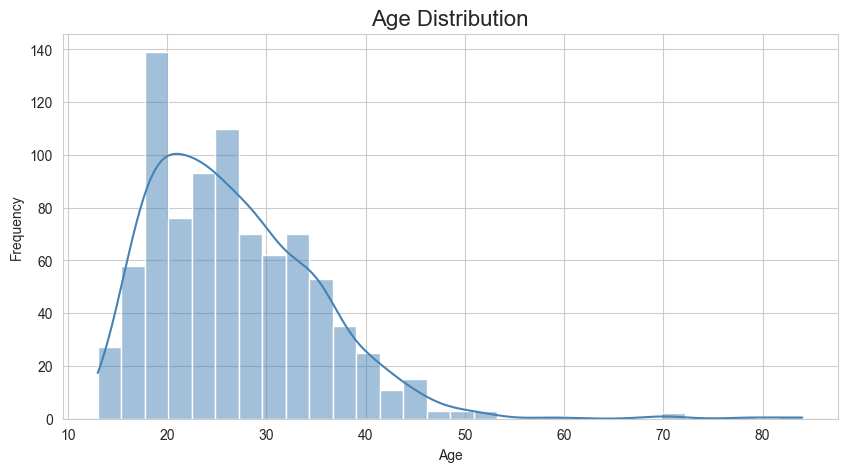

In [14]:
# Age distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

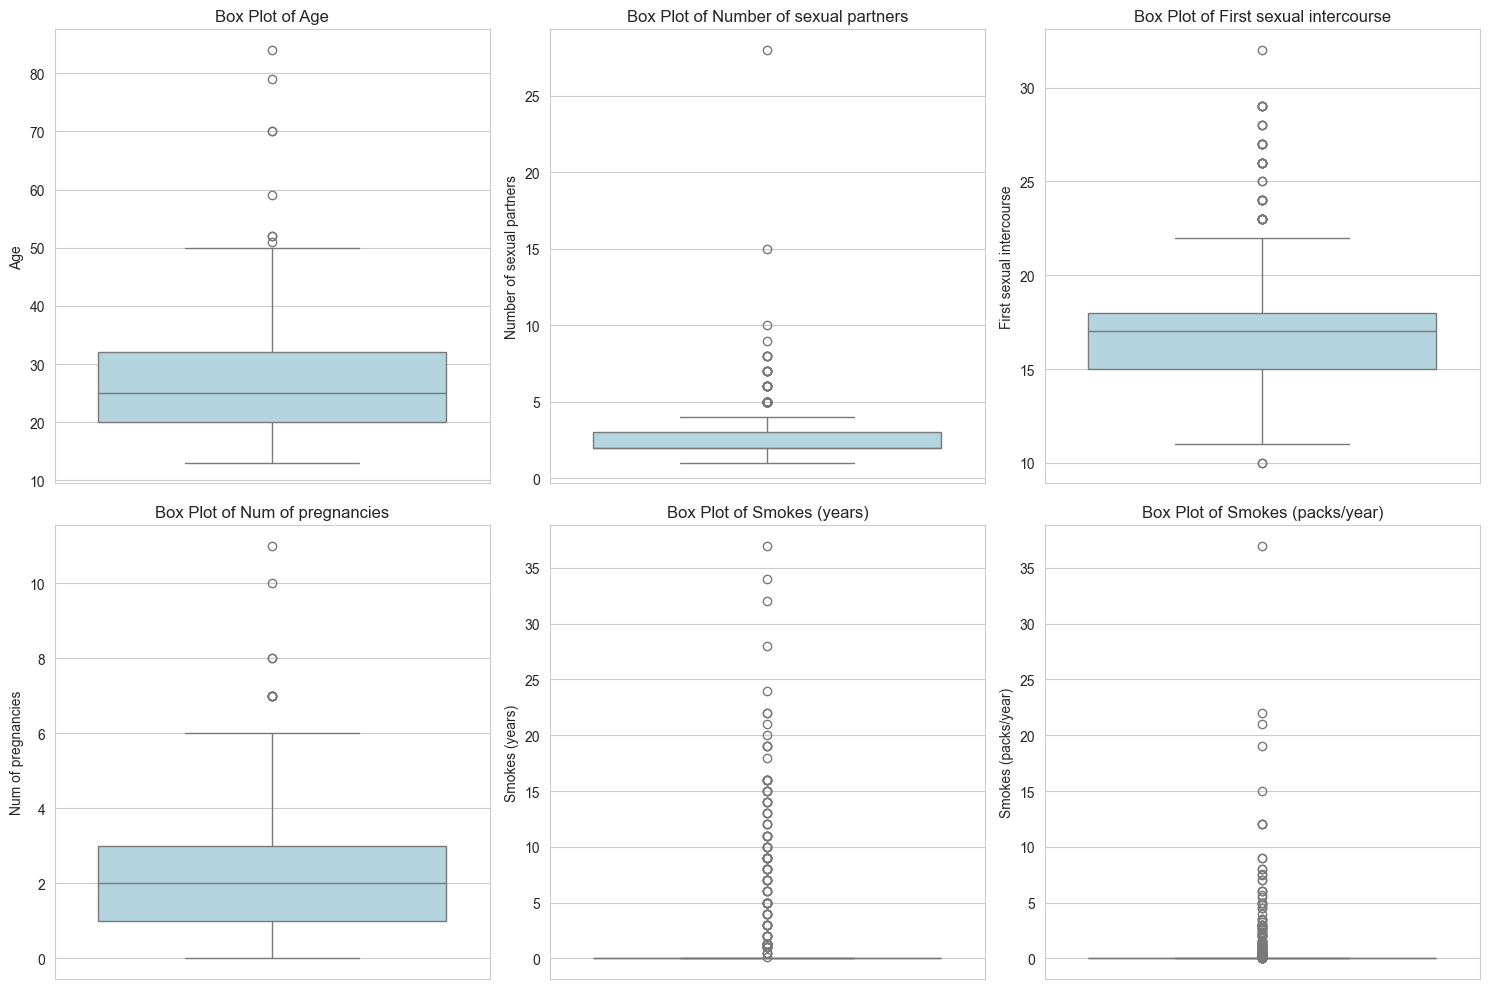

In [15]:
# Box plots for key numeric features
key_features = ['Age', 'Number of sexual partners', 'First sexual intercourse', 
                'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)']

plt.figure(figsize=(15, 10))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f'Box Plot of {col}', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Target Variable Analysis

In [16]:
# Target variable: Biopsy
target = 'Biopsy'
print('Target Variable: Biopsy (0 = Negative, 1 = Positive)')
print(f'\nValue counts:\n{df[target].value_counts()}')
print(f'\nPercentage:\n{df[target].value_counts(normalize=True) * 100}')

Target Variable: Biopsy (0 = Negative, 1 = Positive)

Value counts:
Biopsy
0    803
1     55
Name: count, dtype: int64

Percentage:
Biopsy
0    93.589744
1     6.410256
Name: proportion, dtype: float64


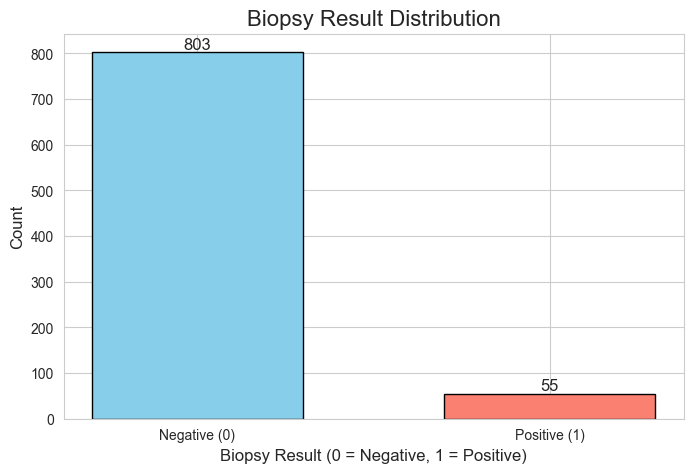

In [17]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
counts = df[target].value_counts()
bars = plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'], edgecolor='black', width=0.6)
plt.title('Biopsy Result Distribution', fontsize=16)
plt.xlabel('Biopsy Result (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)
plt.show()

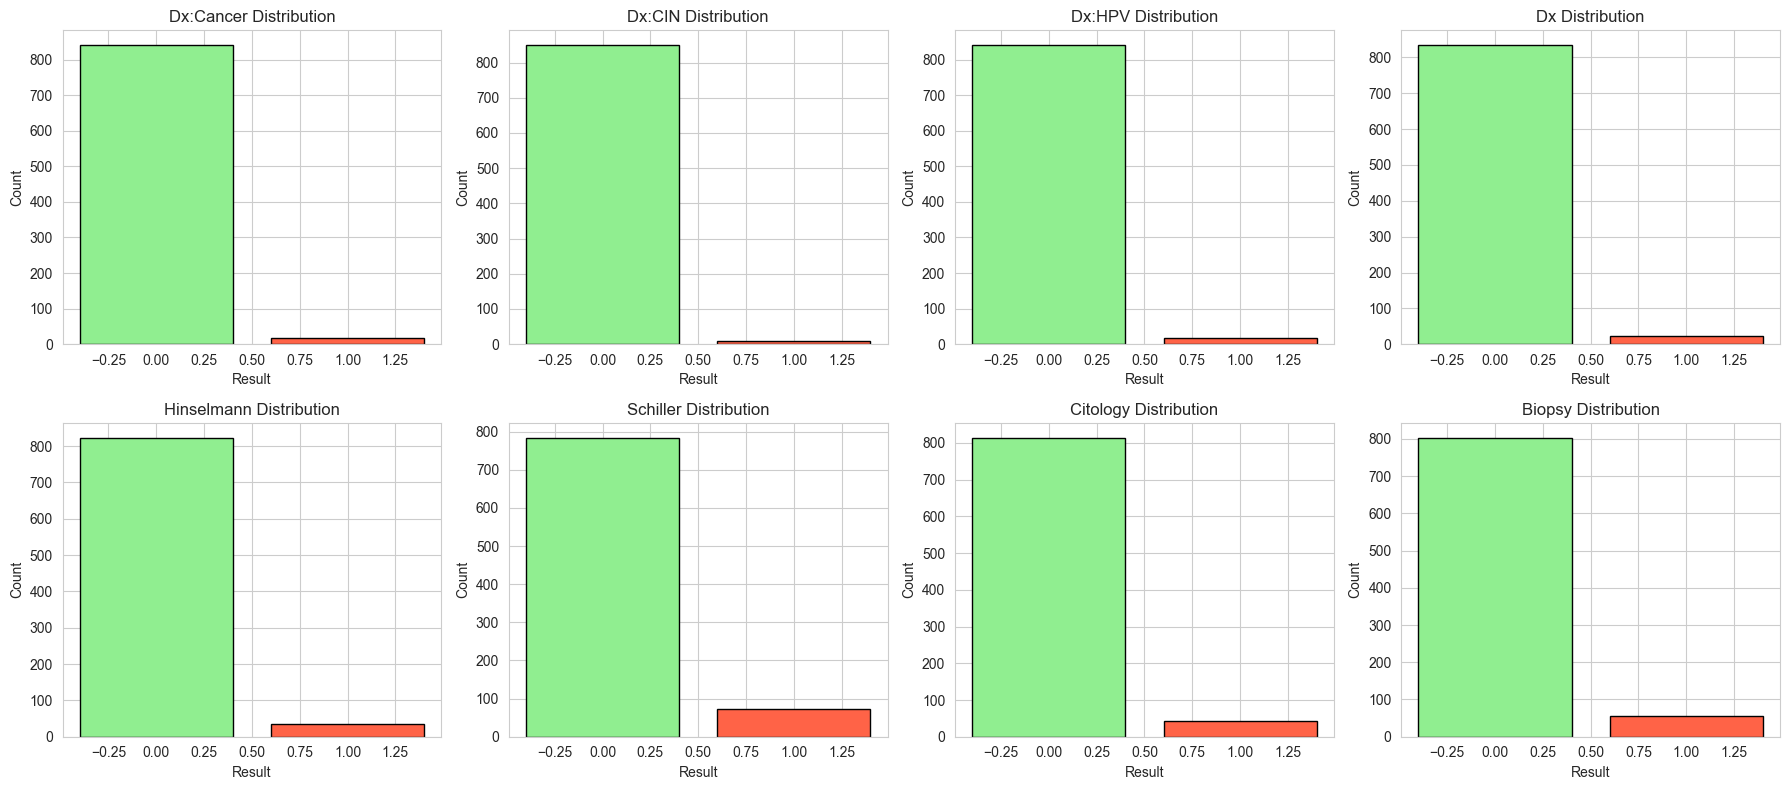

In [18]:
# Also check other diagnosis columns
dx_cols = ['Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(dx_cols):
    if col in df.columns:
        counts = df[col].value_counts()
        axes[i].bar(counts.index, counts.values, color=['lightgreen', 'tomato'], edgecolor='black')
        axes[i].set_title(f'{col} Distribution', fontsize=12)
        axes[i].set_xlabel('Result')
        axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

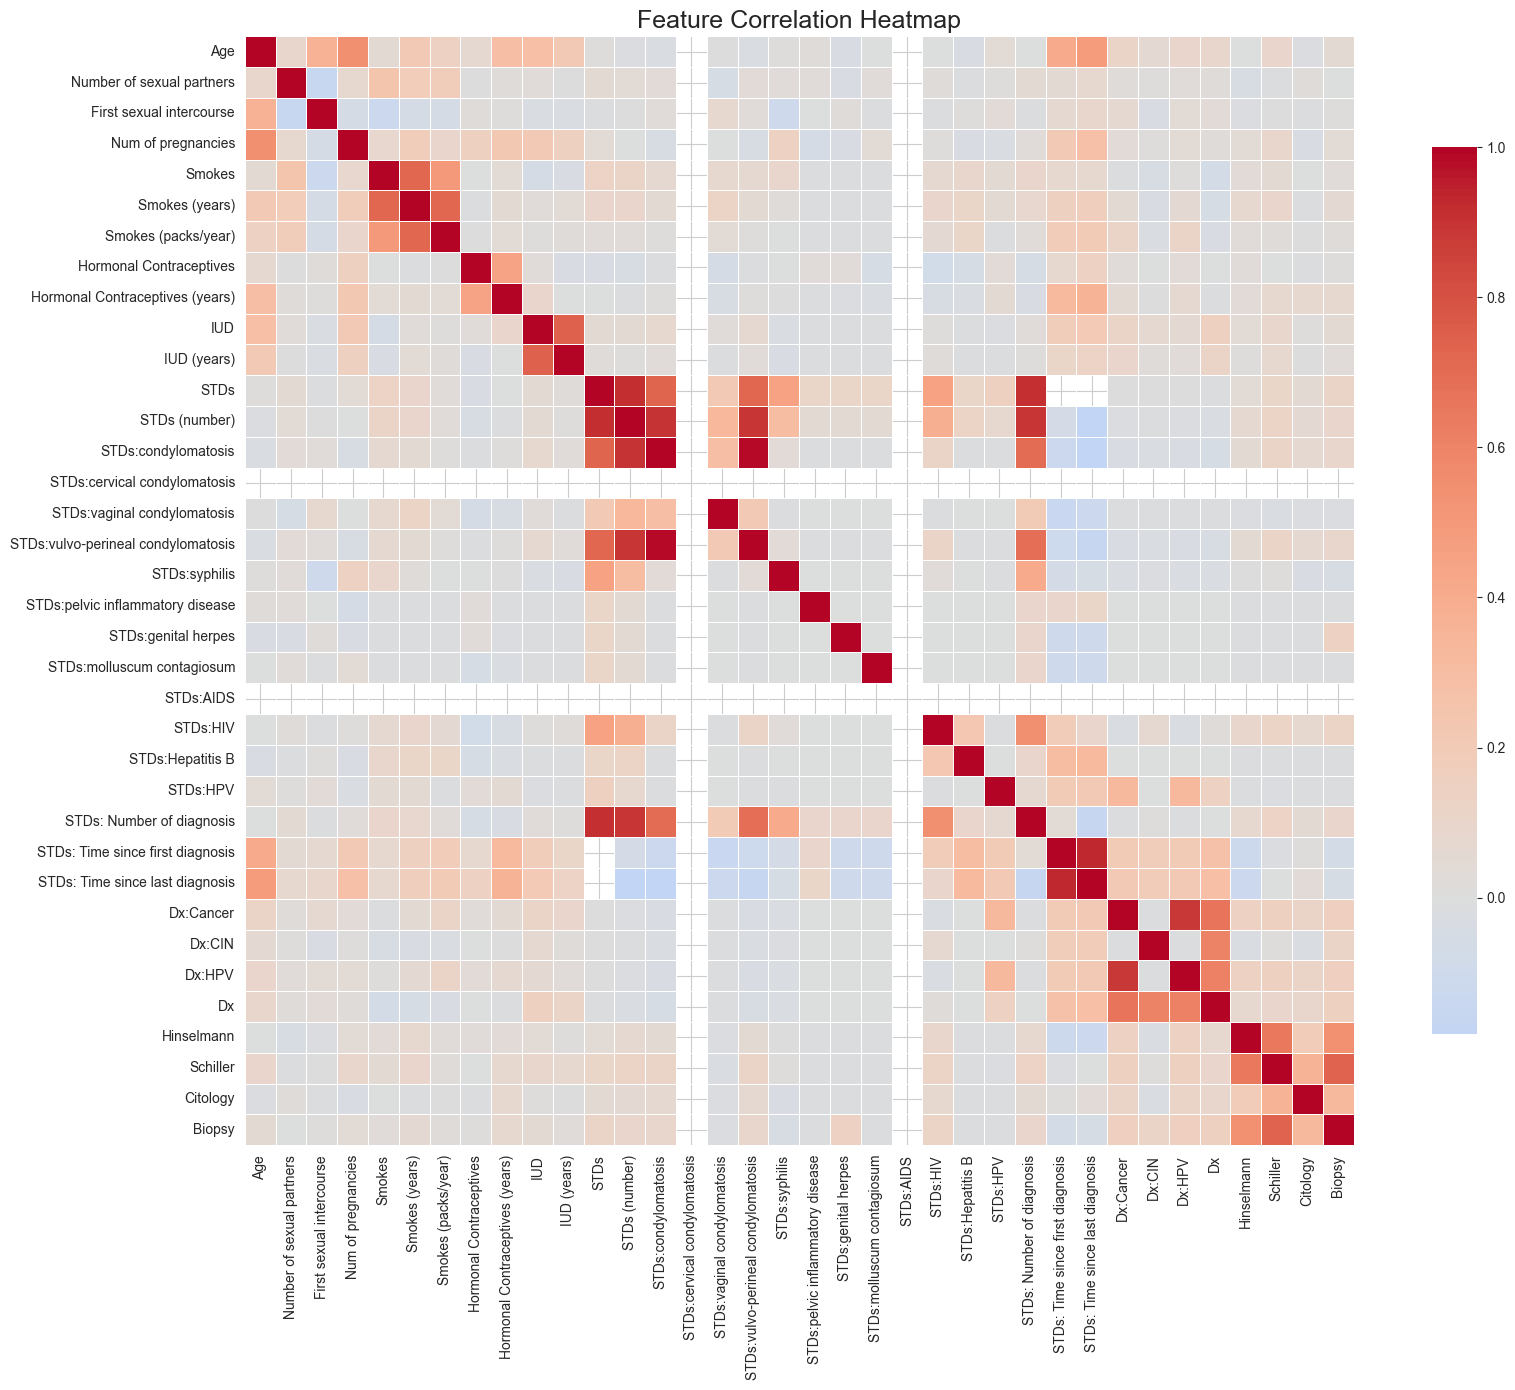

In [19]:
# Correlation heatmap
plt.figure(figsize=(18, 14))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=18)
plt.tight_layout()
plt.show()

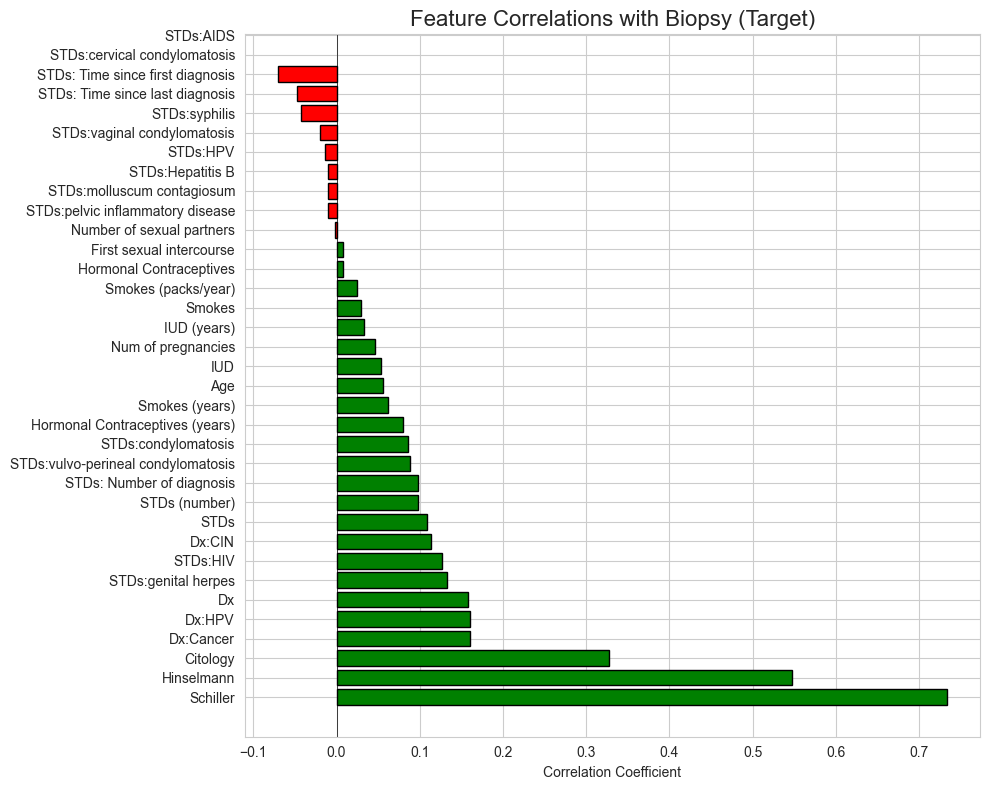

In [20]:
# Top correlations with target (Biopsy)
target_corr = corr_matrix['Biopsy'].drop('Biopsy').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['green' if v > 0 else 'red' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
plt.title('Feature Correlations with Biopsy (Target)', fontsize=16)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

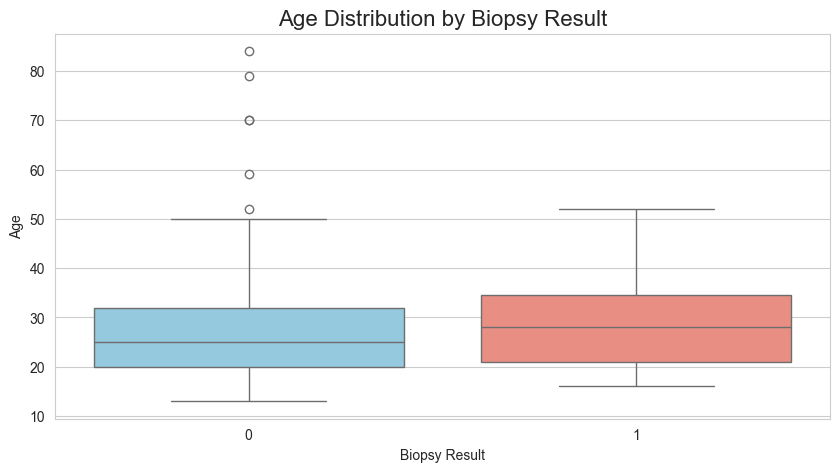

In [21]:
# Age vs Biopsy
plt.figure(figsize=(10, 5))
sns.boxplot(x='Biopsy', y='Age', data=df, palette=['skyblue', 'salmon'])
plt.title('Age Distribution by Biopsy Result', fontsize=16)
plt.xlabel('Biopsy Result')
plt.ylabel('Age')
plt.show()

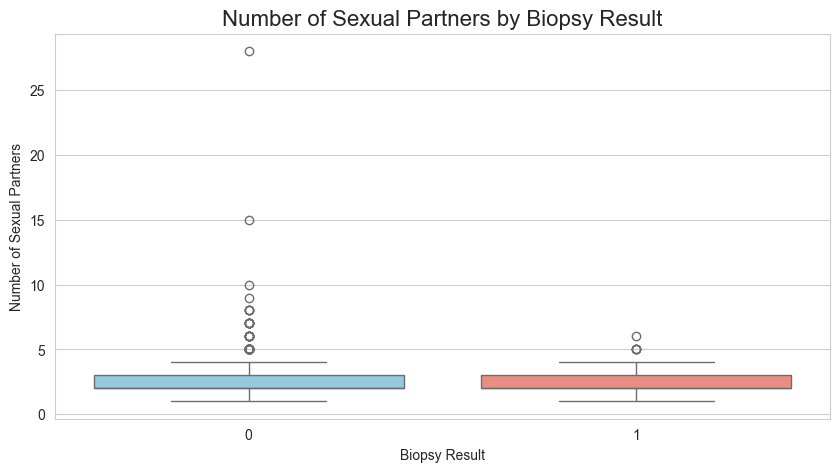

In [22]:
# Number of sexual partners vs Biopsy
plt.figure(figsize=(10, 5))
sns.boxplot(x='Biopsy', y='Number of sexual partners', data=df, palette=['skyblue', 'salmon'])
plt.title('Number of Sexual Partners by Biopsy Result', fontsize=16)
plt.xlabel('Biopsy Result')
plt.ylabel('Number of Sexual Partners')
plt.show()

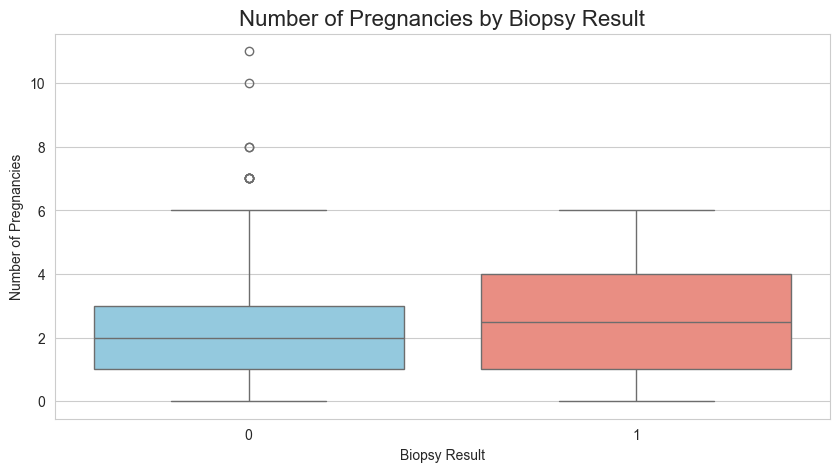

In [23]:
# Num of pregnancies vs Biopsy
plt.figure(figsize=(10, 5))
sns.boxplot(x='Biopsy', y='Num of pregnancies', data=df, palette=['skyblue', 'salmon'])
plt.title('Number of Pregnancies by Biopsy Result', fontsize=16)
plt.xlabel('Biopsy Result')
plt.ylabel('Number of Pregnancies')
plt.show()

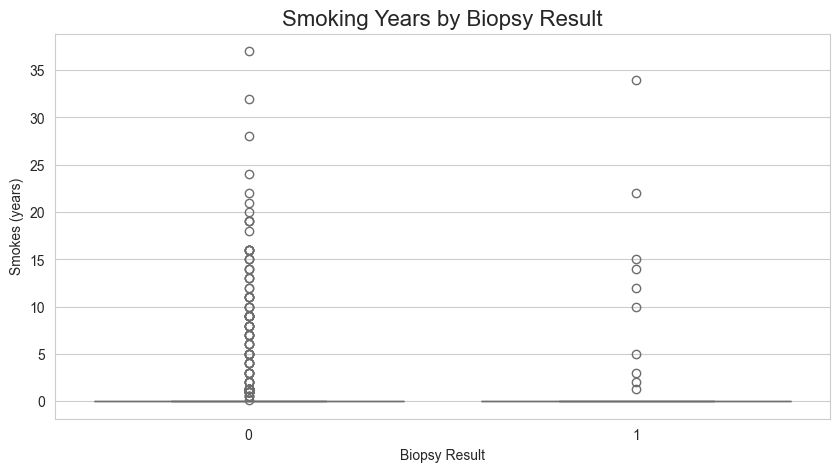

In [24]:
# Smoking years vs Biopsy
plt.figure(figsize=(10, 5))
sns.boxplot(x='Biopsy', y='Smokes (years)', data=df, palette=['skyblue', 'salmon'])
plt.title('Smoking Years by Biopsy Result', fontsize=16)
plt.xlabel('Biopsy Result')
plt.ylabel('Smokes (years)')
plt.show()

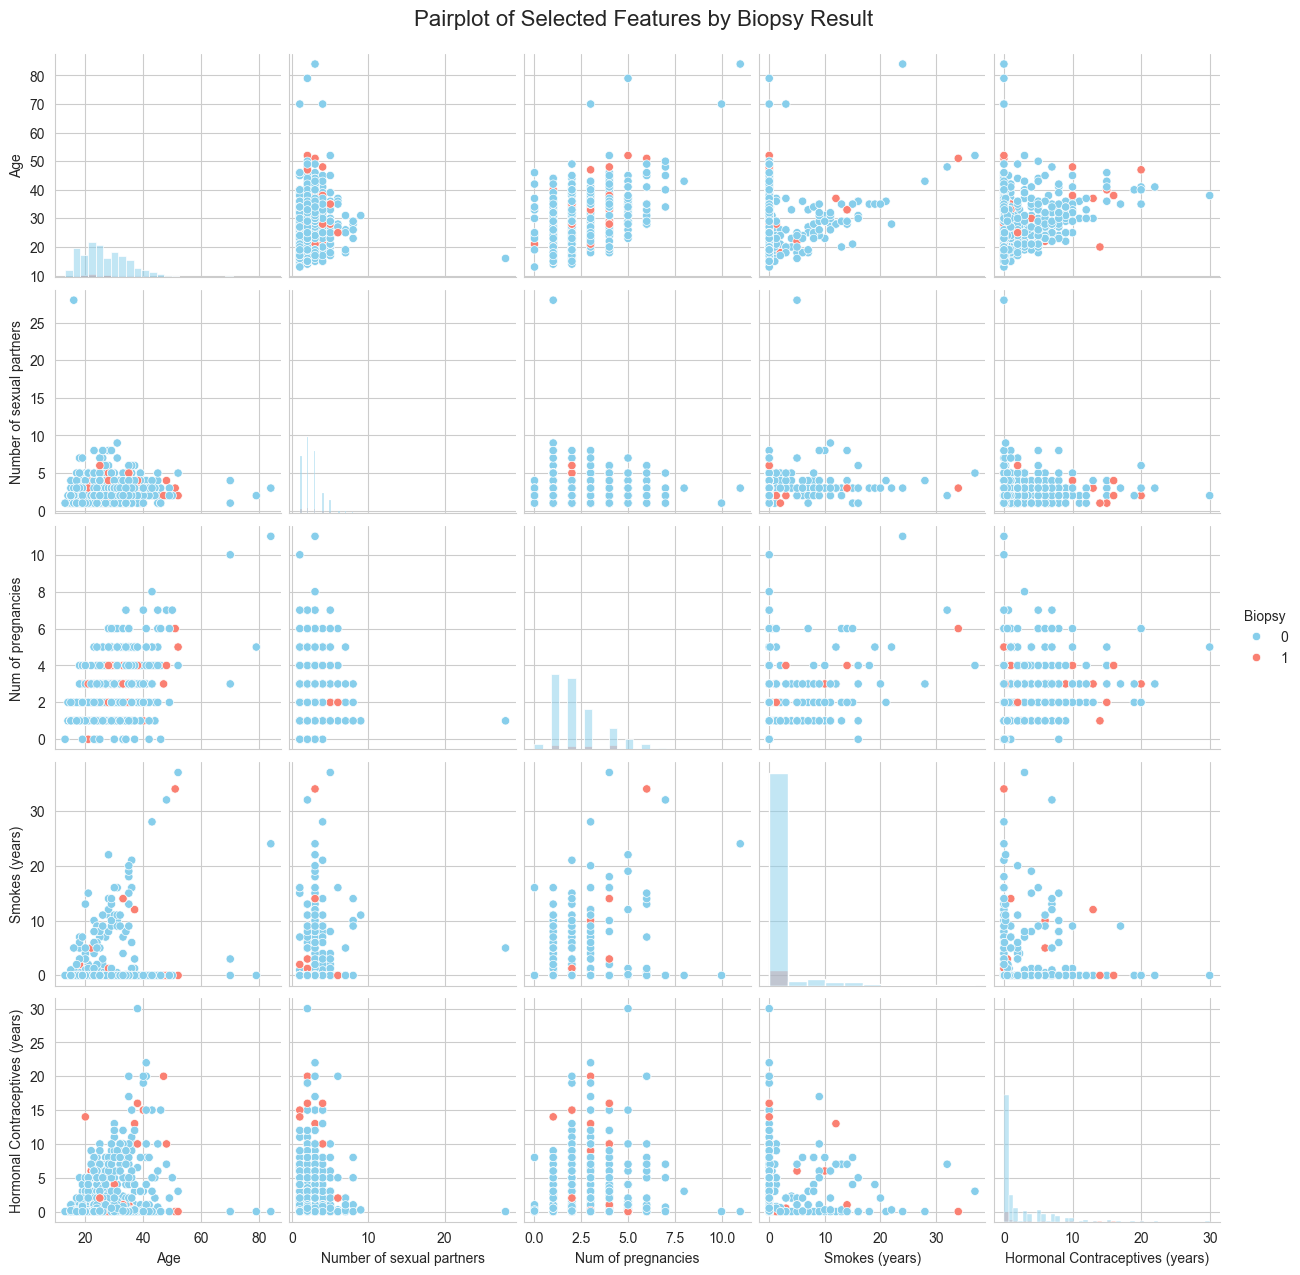

In [25]:
# Pairplot of selected features colored by Biopsy
selected_features = ['Age', 'Number of sexual partners', 'Num of pregnancies', 
                     'Smokes (years)', 'Hormonal Contraceptives (years)', 'Biopsy']

sns.pairplot(df[selected_features].dropna(), hue='Biopsy', palette=['skyblue', 'salmon'], diag_kind='hist')
plt.suptitle('Pairplot of Selected Features by Biopsy Result', y=1.02, fontsize=16)
plt.show()

## 6. Outlier Detection

In [26]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print('Outlier Detection using IQR Method:')
print('=' * 60)
for col in ['Age', 'Number of sexual partners', 'First sexual intercourse', 
            'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)']:
    count, lb, ub = detect_outliers_iqr(df, col)
    print(f'{col:35s} | Outliers: {count:3d} | Range: [{lb:.1f}, {ub:.1f}]')

Outlier Detection using IQR Method:
Age                                 | Outliers:   8 | Range: [2.0, 50.0]
Number of sexual partners           | Outliers:  68 | Range: [0.5, 4.5]
First sexual intercourse            | Outliers:  41 | Range: [10.5, 22.5]
Num of pregnancies                  | Outliers:  10 | Range: [-2.0, 6.0]
Smokes (years)                      | Outliers: 123 | Range: [0.0, 0.0]
Smokes (packs/year)                 | Outliers: 123 | Range: [0.0, 0.0]


## 7. Duplicate Records

In [27]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')
print(f'Percentage of duplicates: {(duplicates / len(df)) * 100:.2f}%')

Number of duplicate rows: 23
Percentage of duplicates: 2.68%


## 8. Key Insights Summary

In [28]:
print('=' * 70)
print('KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS')
print('=' * 70)
print()
print('1. Dataset Shape: {} rows, {} columns'.format(df.shape[0], df.shape[1]))
print()
print('2. Target Variable (Biopsy) is highly imbalanced:')
print(f'   - Negative (0): {df["Biopsy"].value_counts()[0]} samples')
print(f'   - Positive (1): {df["Biopsy"].value_counts()[1]} samples')
print(f'   - Imbalance Ratio: {df["Biopsy"].value_counts(normalize=True)[1]*100:.2f}% positive')
print()
print('3. Missing Values: Several columns have missing values (encoded as "?"):')
print('   - STDs: Time since first diagnosis and STDs: Time since last diagnosis')
print('     have the most missing values')
print('   - Other columns have moderate missing values')
print()
print('4. Key Correlations with Biopsy:')
top_corr = target_corr.head(5)
for col, val in top_corr.items():
    print(f'   - {col}: {val:.3f}')
print()
print('5. Duplicate Records: {} duplicates found'.format(duplicates))
print()
print('6. Data Types: Mixed - need to convert object columns to numeric')
print()
print('7. Next Steps: Feature engineering, handling missing values,')
print('   handling class imbalance (SMOTE), and model training.')

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. Dataset Shape: 858 rows, 36 columns

2. Target Variable (Biopsy) is highly imbalanced:
   - Negative (0): 803 samples
   - Positive (1): 55 samples
   - Imbalance Ratio: 6.41% positive

3. Missing Values: Several columns have missing values (encoded as "?"):
   - STDs: Time since first diagnosis and STDs: Time since last diagnosis
     have the most missing values
   - Other columns have moderate missing values

4. Key Correlations with Biopsy:
   - Schiller: 0.733
   - Hinselmann: 0.547
   - Citology: 0.327
   - Dx:Cancer: 0.161
   - Dx:HPV: 0.161

5. Duplicate Records: 23 duplicates found

6. Data Types: Mixed - need to convert object columns to numeric

7. Next Steps: Feature engineering, handling missing values,
   handling class imbalance (SMOTE), and model training.
